In [1]:
from pathlib import Path
import sys
import platform

print("Python version :", sys.version.split()[0])
print("Python path    :", sys.executable)
print("Operating sys  :", platform.system())
print("Working dir    :", Path.cwd())

Python version : 3.11.16
Python path    : D:\Autonomous_Forest_Navigation\forest_env\python.exe
Operating sys  : Windows
Working dir    : D:\Autonomous_Forest_Navigation


In [2]:
# Project directory configuration

from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()

DATA_DIR = PROJECT_ROOT / "data"
FIGURES_DIR = PROJECT_ROOT / "figures"
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
SRC_DIR = PROJECT_ROOT / "src"

print("Project root :", PROJECT_ROOT)
print("Data         :", DATA_DIR)
print("Figures      :", FIGURES_DIR)
print("Notebooks    :", NOTEBOOKS_DIR)
print("Outputs      :", OUTPUTS_DIR)
print("Source       :", SRC_DIR)

# Verify that all required project folders exist
required_dirs = [
    DATA_DIR,
    FIGURES_DIR,
    NOTEBOOKS_DIR,
    OUTPUTS_DIR,
    SRC_DIR
]

print("\nDirectory check:")
for folder in required_dirs:
    print(f"{folder.name:10s} -> {'OK' if folder.exists() else 'MISSING'}")

Project root : D:\Autonomous_Forest_Navigation
Data         : D:\Autonomous_Forest_Navigation\data
Figures      : D:\Autonomous_Forest_Navigation\figures
Notebooks    : D:\Autonomous_Forest_Navigation\notebooks
Outputs      : D:\Autonomous_Forest_Navigation\outputs
Source       : D:\Autonomous_Forest_Navigation\src

Directory check:
data       -> OK
figures    -> OK
notebooks  -> OK
outputs    -> OK
src        -> OK


In [4]:
# Check scientific and robotics libraries available in this environment

from importlib.util import find_spec

libraries = {
    "NumPy": "numpy",
    "Pandas": "pandas",
    "Matplotlib": "matplotlib",
    "SciPy": "scipy",
    "Scikit-learn": "sklearn",
    "PyProj": "pyproj",
    "Boto3": "boto3",
    "TQDM": "tqdm",
    "Pillow": "PIL",
    "Open3D": "open3d"
}

print("Library check:\n")

for name, module in libraries.items():
    status = "INSTALLED" if find_spec(module) is not None else "MISSING"
    print(f"{name:15s} -> {status}")

Library check:

NumPy           -> INSTALLED
Pandas          -> INSTALLED
Matplotlib      -> INSTALLED
SciPy           -> INSTALLED
Scikit-learn    -> INSTALLED
PyProj          -> INSTALLED
Boto3           -> INSTALLED
TQDM            -> INSTALLED
Pillow          -> INSTALLED
Open3D          -> MISSING


In [5]:
# Connect to the public FoMo dataset on AWS S3

import boto3
from botocore import UNSIGNED
from botocore.config import Config

BUCKET = "fomo-dataset"
DATA_PREFIX = "data/"

s3 = boto3.client(
    "s3",
    config=Config(signature_version=UNSIGNED)
)

print("Connected to public FoMo bucket")
print("Bucket :", BUCKET)
print("Prefix :", DATA_PREFIX)

Connected to public FoMo bucket
Bucket : fomo-dataset
Prefix : data/


In [6]:
# List available FoMo deployments from the public S3 bucket

def list_prefixes(prefix="", delimiter="/"):
    response = s3.list_objects_v2(
        Bucket=BUCKET,
        Prefix=prefix,
        Delimiter=delimiter
    )
    
    return [
        item["Prefix"]
        for item in response.get("CommonPrefixes", [])
    ]


deployments = list_prefixes(DATA_PREFIX)

print(f"Found {len(deployments)} deployments:\n")

for deployment in deployments:
    print(deployment)

Found 12 deployments:

data/2024-11-21/
data/2024-11-28/
data/2025-01-10/
data/2025-01-29/
data/2025-03-10/
data/2025-04-15/
data/2025-05-28/
data/2025-06-26/
data/2025-08-20/
data/2025-09-24/
data/2025-10-14/
data/2025-11-03/


In [7]:
# Select a summer deployment and inspect its available sessions

SELECTED_DEPLOYMENT = "data/2025-06-26/"

sessions = list_prefixes(SELECTED_DEPLOYMENT)

print("Selected deployment :", SELECTED_DEPLOYMENT)
print(f"Found {len(sessions)} sessions:\n")

for i, session in enumerate(sessions, start=1):
    print(f"{i:2d}. {session}")

Selected deployment : data/2025-06-26/
Found 6 sessions:

 1. data/2025-06-26/blue_2025-06-26-10-35/
 2. data/2025-06-26/green_2025-06-26-11-20/
 3. data/2025-06-26/magenta_2025-06-26-12-04/
 4. data/2025-06-26/orange_2025-06-26-10-48/
 5. data/2025-06-26/red_2025-06-26-10-31/
 6. data/2025-06-26/yellow_2025-06-26-14-42/


In [8]:
# Inspect the internal structure of a candidate forest trajectory

SELECTED_SESSION = "data/2025-06-26/orange_2025-06-26-10-48/"

session_contents = list_prefixes(SELECTED_SESSION)

print("Candidate session:")
print(SELECTED_SESSION)

print(f"\nFound {len(session_contents)} top-level folders:\n")

for i, item in enumerate(session_contents, start=1):
    folder_name = item.rstrip("/").split("/")[-1]
    print(f"{i:2d}. {folder_name}")

Candidate session:
data/2025-06-26/orange_2025-06-26-10-48/

Found 10 top-level folders:

 1. audio_left
 2. audio_right
 3. basler
 4. calib
 5. leishen
 6. metadata
 7. navtech
 8. robosense
 9. zedx_left
10. zedx_right


In [9]:
# Inspect all top-level folders and files in the selected session
# Nothing is downloaded in this cell.

response = s3.list_objects_v2(
    Bucket=BUCKET,
    Prefix=SELECTED_SESSION,
    Delimiter="/"
)

print("SESSION STRUCTURE")
print("=" * 70)

# Folders
folders = response.get("CommonPrefixes", [])

print("\nFOLDERS:")
for item in folders:
    name = item["Prefix"].rstrip("/").split("/")[-1]
    print(f"  [DIR]  {name}")

# Files located directly inside the session
files = []

for item in response.get("Contents", []):
    key = item["Key"]

    # Ignore the session directory marker itself
    if key == SELECTED_SESSION:
        continue

    filename = key.split("/")[-1]

    if filename:
        size_mb = item["Size"] / (1024 ** 2)
        files.append((filename, size_mb))

print("\nTOP-LEVEL FILES:")

if files:
    for filename, size_mb in files:
        print(f"  [FILE] {filename:45s} {size_mb:8.3f} MB")
else:
    print("  No top-level files found.")

SESSION STRUCTURE

FOLDERS:
  [DIR]  audio_left
  [DIR]  audio_right
  [DIR]  basler
  [DIR]  calib
  [DIR]  leishen
  [DIR]  metadata
  [DIR]  navtech
  [DIR]  robosense
  [DIR]  zedx_left
  [DIR]  zedx_right

TOP-LEVEL FILES:
  [FILE] CHANGELOG.md                                     0.001 MB
  [FILE] odom.csv                                         2.723 MB
  [FILE] vectornav.csv                                   38.750 MB
  [FILE] xsens.csv                                       38.775 MB


In [10]:
# Inspect CSV headers and check whether ground-truth files exist
# Only a few KB are read from S3 — no large files are downloaded.

from botocore.exceptions import ClientError

print("SENSOR FILE PREVIEW")
print("=" * 80)

csv_files = [
    "odom.csv",
    "vectornav.csv",
    "xsens.csv"
]

for filename in csv_files:
    key = SELECTED_SESSION + filename

    obj = s3.get_object(
        Bucket=BUCKET,
        Key=key,
        Range="bytes=0-4095"
    )

    text = obj["Body"].read().decode("utf-8", errors="replace")
    lines = text.splitlines()

    print(f"\n{filename}")
    print("-" * 80)

    if len(lines) >= 1:
        print("Header:")
        print(lines[0])

    if len(lines) >= 2:
        print("\nFirst data row:")
        print(lines[1])


print("\n\nGROUND-TRUTH CHECK")
print("=" * 80)

possible_gt_files = [
    "gt.txt",
    "gt_cov.txt",
    "ground_truth.txt",
    "groundtruth.txt"
]

for filename in possible_gt_files:
    key = SELECTED_SESSION + filename

    try:
        info = s3.head_object(
            Bucket=BUCKET,
            Key=key
        )

        size_mb = info["ContentLength"] / (1024 ** 2)
        print(f"{filename:20s} -> FOUND ({size_mb:.3f} MB)")

    except ClientError as e:
        if e.response["Error"]["Code"] in ("404", "NoSuchKey"):
            print(f"{filename:20s} -> not found")
        else:
            raise

SENSOR FILE PREVIEW

odom.csv
--------------------------------------------------------------------------------
Header:
t,px,py,pz,qx,qy,qz,qw,tlx,tly,tlz,tax,tay,taz,tax,tay,taz

First data row:
1750949314587300,0,0,0,0,0,0,1,0,0,0,0,0,0

vectornav.csv
--------------------------------------------------------------------------------
Header:
t,wx,wy,wz,ax,ay,az

First data row:
1750949311311430,0.0005900439573451877,0.003136055776849389,-0.011490195989608765,0.25873708724975586,-0.2583908438682556,9.710453033447266

xsens.csv
--------------------------------------------------------------------------------
Header:
t,wx,wy,wz,ax,ay,az

First data row:
1750949311314741,-0.004330338444560766,-0.006183946970850229,0.0011629951186478138,-0.3061659336090088,-0.2729172706604004,9.838909149169922


GROUND-TRUTH CHECK
gt.txt               -> not found
gt_cov.txt           -> not found
ground_truth.txt     -> not found
groundtruth.txt      -> not found


In [11]:
# Search the whole selected session for GNSS / GPS / ground-truth related files.
# This only lists S3 object names; it does not download the dataset.

search_terms = [
    "gnss",
    "gps",
    "ppk",
    "ground",
    "truth",
    "gt",
    "pose",
    "trajectory",
    "utm",
    "rtk"
]

matches = []

paginator = s3.get_paginator("list_objects_v2")

for page in paginator.paginate(
    Bucket=BUCKET,
    Prefix=SELECTED_SESSION
):
    for obj in page.get("Contents", []):
        key = obj["Key"]
        key_lower = key.lower()

        if any(term in key_lower for term in search_terms):
            matches.append(
                (key, obj["Size"] / (1024 ** 2))
            )

print("GNSS / GROUND-TRUTH SEARCH")
print("=" * 90)

if matches:
    for key, size_mb in matches:
        relative = key.replace(SELECTED_SESSION, "")
        print(f"{relative:70s} {size_mb:8.3f} MB")
else:
    print("No matching files found.")

GNSS / GROUND-TRUTH SEARCH
No matching files found.


In [12]:
# Check which June 26 sessions actually contain ground-truth files

print("GROUND-TRUTH AVAILABILITY — 2025-06-26")
print("=" * 90)

for session in sessions:
    response = s3.list_objects_v2(
        Bucket=BUCKET,
        Prefix=session,
        Delimiter="/"
    )

    top_level_files = {
        obj["Key"].split("/")[-1]
        for obj in response.get("Contents", [])
        if obj["Key"] != session
    }

    session_name = session.rstrip("/").split("/")[-1]

    has_gt = "gt.txt" in top_level_files
    has_odom = "odom.csv" in top_level_files
    has_vectornav = "vectornav.csv" in top_level_files
    has_xsens = "xsens.csv" in top_level_files

    print(
        f"{session_name:35s} "
        f"GT: {'YES' if has_gt else 'NO ':3s} | "
        f"ODOM: {'YES' if has_odom else 'NO ':3s} | "
        f"VectorNav: {'YES' if has_vectornav else 'NO ':3s} | "
        f"XSens: {'YES' if has_xsens else 'NO ':3s}"
    )

GROUND-TRUTH AVAILABILITY — 2025-06-26
blue_2025-06-26-10-35               GT: YES | ODOM: YES | VectorNav: YES | XSens: YES
green_2025-06-26-11-20              GT: YES | ODOM: YES | VectorNav: YES | XSens: YES
magenta_2025-06-26-12-04            GT: YES | ODOM: YES | VectorNav: YES | XSens: YES
orange_2025-06-26-10-48             GT: NO  | ODOM: YES | VectorNav: YES | XSens: YES
red_2025-06-26-10-31                GT: YES | ODOM: YES | VectorNav: YES | XSens: YES
yellow_2025-06-26-14-42             GT: NO  | ODOM: YES | VectorNav: YES | XSens: YES


In [13]:
# Select the Green summer trajectory as our main development sequence

SELECTED_SESSION = "data/2025-06-26/green_2025-06-26-11-20/"

GT_KEY = SELECTED_SESSION + "gt.txt"

# Get ground-truth file information
gt_info = s3.head_object(
    Bucket=BUCKET,
    Key=GT_KEY
)

gt_size_mb = gt_info["ContentLength"] / (1024 ** 2)

print("SELECTED SESSION")
print("=" * 80)
print(SELECTED_SESSION)

print("\nGround-truth file:")
print(f"gt.txt size: {gt_size_mb:.3f} MB")


# Read only the first few KB to inspect its structure
obj = s3.get_object(
    Bucket=BUCKET,
    Key=GT_KEY,
    Range="bytes=0-4095"
)

preview = obj["Body"].read().decode("utf-8", errors="replace")

print("\nGROUND-TRUTH PREVIEW")
print("=" * 80)

lines = preview.splitlines()

for line in lines[:6]:
    print(line)

SELECTED SESSION
data/2025-06-26/green_2025-06-26-11-20/

Ground-truth file:
gt.txt size: 0.558 MB

GROUND-TRUTH PREVIEW
1750951238.994999808 255999.693251046 5242941.394184130 629.171673633 0 0 0 1
1750951239.095000064 255999.691780726 5242941.394411759 629.173665395 0 0 0 1
1750951239.194999808 255999.690541631 5242941.399303862 629.169579190 0 0 0 1
1750951239.295000064 255999.691623954 5242941.397881394 629.171059201 0 0 0 1
1750951239.395000064 255999.691356430 5242941.398381514 629.170816195 0 0 0 1
1750951239.494999808 255999.693299324 5242941.395377444 629.166310267 0 0 0 1


In [14]:
# Download the selected ground-truth trajectory into our project data folder

LOCAL_SESSION_DIR = (
    DATA_DIR
    / "fomo"
    / "2025-06-26"
    / "green_2025-06-26-11-20"
)

LOCAL_SESSION_DIR.mkdir(parents=True, exist_ok=True)

LOCAL_GT_FILE = LOCAL_SESSION_DIR / "gt.txt"

s3.download_file(
    BUCKET,
    GT_KEY,
    str(LOCAL_GT_FILE)
)

print("Ground truth downloaded successfully.")
print("Saved to :", LOCAL_GT_FILE)
print(
    "Size     :",
    f"{LOCAL_GT_FILE.stat().st_size / (1024 ** 2):.3f} MB"
)

Ground truth downloaded successfully.
Saved to : D:\Autonomous_Forest_Navigation\data\fomo\2025-06-26\green_2025-06-26-11-20\gt.txt
Size     : 0.558 MB


In [15]:
# Load and analyze the complete ground-truth trajectory

import numpy as np
import pandas as pd

gt_columns = [
    "timestamp",
    "x", "y", "z",
    "qx", "qy", "qz", "qw"
]

gt = pd.read_csv(
    LOCAL_GT_FILE,
    sep=r"\s+",
    names=gt_columns
)

# Basic statistics
num_poses = len(gt)

duration_sec = (
    gt["timestamp"].iloc[-1]
    - gt["timestamp"].iloc[0]
)

# Distance travelled between consecutive poses
positions = gt[["x", "y", "z"]].to_numpy()

step_distances = np.linalg.norm(
    np.diff(positions, axis=0),
    axis=1
)

total_distance = step_distances.sum()

# Horizontal distance only
xy_positions = gt[["x", "y"]].to_numpy()

horizontal_distance = np.linalg.norm(
    np.diff(xy_positions, axis=0),
    axis=1
).sum()

# Check whether quaternion orientation changes
quaternions = gt[["qx", "qy", "qz", "qw"]]

unique_quaternions = quaternions.drop_duplicates()

print("GROUND-TRUTH TRAJECTORY SUMMARY")
print("=" * 55)

print(f"Number of poses       : {num_poses:,}")
print(f"Duration              : {duration_sec:.2f} s")
print(f"Duration              : {duration_sec / 60:.2f} min")
print(f"3D distance travelled : {total_distance:.2f} m")
print(f"XY distance travelled : {horizontal_distance:.2f} m")

print("\nCOORDINATE RANGE")
print("=" * 55)

print(f"X : {gt['x'].min():.3f} → {gt['x'].max():.3f}")
print(f"Y : {gt['y'].min():.3f} → {gt['y'].max():.3f}")
print(f"Z : {gt['z'].min():.3f} → {gt['z'].max():.3f}")

print("\nORIENTATION")
print("=" * 55)

print(f"Unique quaternions : {len(unique_quaternions):,}")

print("\nFirst 5 poses:")
display(gt.head())

GROUND-TRUTH TRAJECTORY SUMMARY
Number of poses       : 7,504
Duration              : 750.30 s
Duration              : 12.51 min
3D distance travelled : 818.05 m
XY distance travelled : 801.09 m

COORDINATE RANGE
X : 255879.350 → 256115.690
Y : 5242905.629 → 5243081.477
Z : 628.430 → 647.211

ORIENTATION
Unique quaternions : 1

First 5 poses:


,timestamp,x,y,z,qx,qy,qz,qw
0,1.750951e+09,255999.693251,5.242941e+06,629.171674,0,0,0,1
1,1.750951e+09,255999.691781,5.242941e+06,629.173665,0,0,0,1
2,1.750951e+09,255999.690542,5.242941e+06,629.169579,0,0,0,1
3,1.750951e+09,255999.691624,5.242941e+06,629.171059,0,0,0,1
4,1.750951e+09,255999.691356,5.242941e+06,629.170816,0,0,0,1


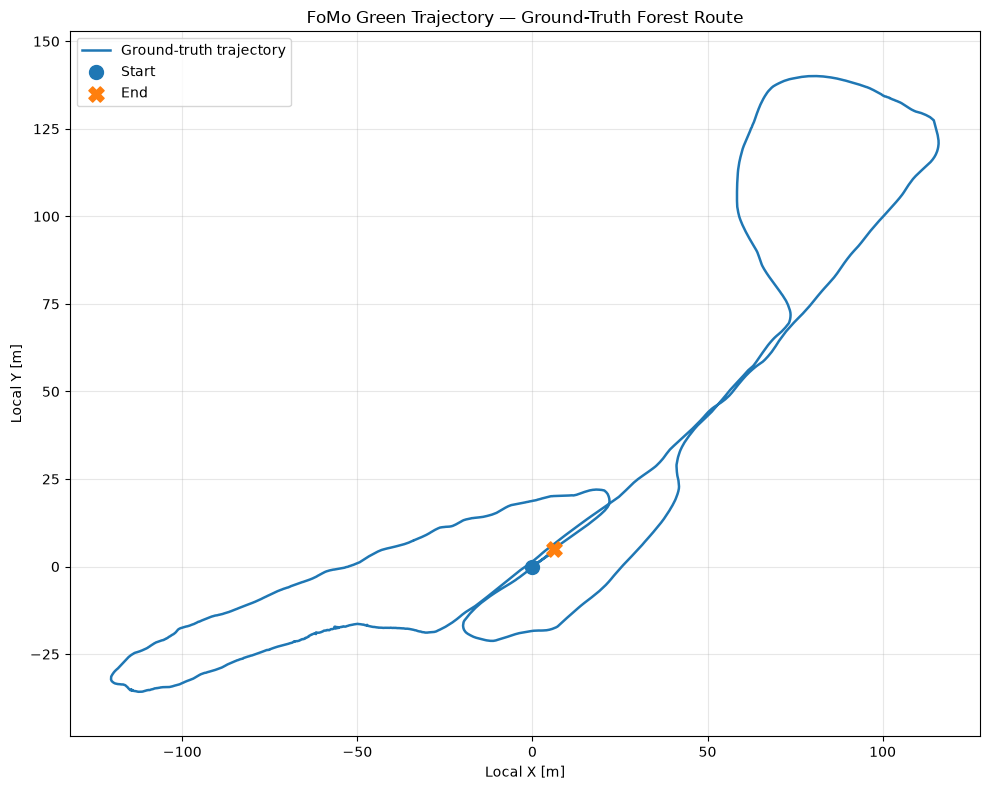

Figure saved to:
D:\Autonomous_Forest_Navigation\figures\green_ground_truth_trajectory.png


In [16]:
# Plot the 2D ground-truth trajectory using local coordinates

import matplotlib.pyplot as plt

# Convert large map coordinates to local coordinates
# so the plot starts near (0, 0)
x_local = gt["x"] - gt["x"].iloc[0]
y_local = gt["y"] - gt["y"].iloc[0]

fig, ax = plt.subplots(figsize=(10, 8))

# Full trajectory
ax.plot(
    x_local,
    y_local,
    linewidth=1.8,
    label="Ground-truth trajectory"
)

# Start point
ax.scatter(
    x_local.iloc[0],
    y_local.iloc[0],
    s=100,
    marker="o",
    label="Start",
    zorder=5
)

# End point
ax.scatter(
    x_local.iloc[-1],
    y_local.iloc[-1],
    s=120,
    marker="X",
    label="End",
    zorder=5
)

ax.set_title(
    "FoMo Green Trajectory — Ground-Truth Forest Route"
)
ax.set_xlabel("Local X [m]")
ax.set_ylabel("Local Y [m]")

ax.axis("equal")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()

# Save figure inside the project
trajectory_figure = FIGURES_DIR / "green_ground_truth_trajectory.png"

plt.savefig(
    trajectory_figure,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("Figure saved to:")
print(trajectory_figure)

In [17]:
# Check sizes of the main localization sensor files
# Nothing is downloaded in this cell.

sensor_files = [
    "vectornav.csv",
    "xsens.csv",
    "odom.csv"
]

print("GREEN SESSION — LOCALIZATION SENSOR FILES")
print("=" * 65)

sensor_sizes = {}

for filename in sensor_files:
    key = SELECTED_SESSION + filename

    info = s3.head_object(
        Bucket=BUCKET,
        Key=key
    )

    size_mb = info["ContentLength"] / (1024 ** 2)
    sensor_sizes[filename] = size_mb

    print(f"{filename:20s} : {size_mb:8.3f} MB")

GREEN SESSION — LOCALIZATION SENSOR FILES
vectornav.csv        :   19.656 MB
xsens.csv            :   19.656 MB
odom.csv             :    1.387 MB


In [18]:
# Download the primary IMU and odometry files into the project

files_to_download = [
    "vectornav.csv",
    "odom.csv"
]

print("DOWNLOADING LOCALIZATION DATA")
print("=" * 60)

for filename in files_to_download:
    s3_key = SELECTED_SESSION + filename
    local_file = LOCAL_SESSION_DIR / filename

    s3.download_file(
        BUCKET,
        s3_key,
        str(local_file)
    )

    size_mb = local_file.stat().st_size / (1024 ** 2)

    print(f"{filename:20s} -> {size_mb:.3f} MB")
    print(f"Saved to: {local_file}\n")

print("Download complete.")

DOWNLOADING LOCALIZATION DATA
vectornav.csv        -> 19.656 MB
Saved to: D:\Autonomous_Forest_Navigation\data\fomo\2025-06-26\green_2025-06-26-11-20\vectornav.csv

odom.csv             -> 1.387 MB
Saved to: D:\Autonomous_Forest_Navigation\data\fomo\2025-06-26\green_2025-06-26-11-20\odom.csv

Download complete.


In [19]:
# Load and inspect the VectorNav IMU data

import numpy as np
import pandas as pd

VECTORNAV_FILE = LOCAL_SESSION_DIR / "vectornav.csv"

imu = pd.read_csv(VECTORNAV_FILE)

print("VECTORNAV IMU ANALYSIS")
print("=" * 65)

print(f"Number of IMU samples : {len(imu):,}")
print(f"Columns               : {list(imu.columns)}")

# ---------------------------------------------------------
# Determine timestamp scale relative to ground-truth time
# ---------------------------------------------------------

possible_scales = [
    1,
    1e3,
    1e6,
    1e7,
    1e9
]

gt_reference_time = gt["timestamp"].median()
imu_raw_time = imu["t"].median()

timestamp_scale = min(
    possible_scales,
    key=lambda scale: abs(
        np.log10((imu_raw_time / scale) / gt_reference_time)
    )
)

imu["timestamp"] = imu["t"] / timestamp_scale

print(f"Detected timestamp scale : {timestamp_scale:g}")
print(f"First IMU timestamp      : {imu['timestamp'].iloc[0]:.6f}")
print(f"Last IMU timestamp       : {imu['timestamp'].iloc[-1]:.6f}")

# ---------------------------------------------------------
# Sampling rate
# ---------------------------------------------------------

dt = np.diff(imu["timestamp"].to_numpy())

valid_dt = dt[dt > 0]

median_dt = np.median(valid_dt)
sampling_rate = 1.0 / median_dt

imu_duration = (
    imu["timestamp"].iloc[-1]
    - imu["timestamp"].iloc[0]
)

print("\nTIMING")
print("=" * 65)

print(f"Duration               : {imu_duration:.2f} s")
print(f"Duration               : {imu_duration / 60:.2f} min")
print(f"Median sample interval : {median_dt:.6f} s")
print(f"Estimated sample rate  : {sampling_rate:.2f} Hz")
print(f"Non-positive time gaps : {(dt <= 0).sum():,}")

# ---------------------------------------------------------
# Missing values
# ---------------------------------------------------------

print("\nDATA QUALITY")
print("=" * 65)

print(f"Missing values         : {imu.isna().sum().sum():,}")
print(f"Duplicate timestamps   : {imu['t'].duplicated().sum():,}")

# ---------------------------------------------------------
# Sensor ranges
# ---------------------------------------------------------

print("\nGYROSCOPE RANGE [rad/s]")
print("=" * 65)

for col in ["wx", "wy", "wz"]:
    print(
        f"{col}: "
        f"{imu[col].min():9.4f}  ->  "
        f"{imu[col].max():9.4f}"
    )

print("\nACCELEROMETER RANGE [m/s²]")
print("=" * 65)

for col in ["ax", "ay", "az"]:
    print(
        f"{col}: "
        f"{imu[col].min():9.4f}  ->  "
        f"{imu[col].max():9.4f}"
    )

# ---------------------------------------------------------
# Check overlap with ground truth
# ---------------------------------------------------------

gt_start = gt["timestamp"].iloc[0]
gt_end = gt["timestamp"].iloc[-1]

imu_start = imu["timestamp"].iloc[0]
imu_end = imu["timestamp"].iloc[-1]

overlap_start = max(gt_start, imu_start)
overlap_end = min(gt_end, imu_end)

overlap_duration = max(0, overlap_end - overlap_start)

print("\nGROUND TRUTH / IMU SYNCHRONIZATION")
print("=" * 65)

print(f"GT start       : {gt_start:.6f}")
print(f"GT end         : {gt_end:.6f}")
print(f"IMU start      : {imu_start:.6f}")
print(f"IMU end        : {imu_end:.6f}")
print(f"Overlap        : {overlap_duration:.2f} s")
print(f"Overlap        : {overlap_duration / 60:.2f} min")

print("\nFirst 5 IMU samples:")
display(imu.head())

VECTORNAV IMU ANALYSIS
Number of IMU samples : 150,035
Columns               : ['t', 'wx', 'wy', 'wz', 'ax', 'ay', 'az']
Detected timestamp scale : 1e+06
First IMU timestamp      : 1750951238.935009
Last IMU timestamp       : 1750951989.315341

TIMING
Duration               : 750.38 s
Duration               : 12.51 min
Median sample interval : 0.005001 s
Estimated sample rate  : 199.96 Hz
Non-positive time gaps : 0

DATA QUALITY
Missing values         : 0
Duplicate timestamps   : 0

GYROSCOPE RANGE [rad/s]
wx:   -0.7125  ->     0.7029
wy:   -0.4940  ->     0.3880
wz:   -0.5342  ->     0.5683

ACCELEROMETER RANGE [m/s²]
ax:   -5.0035  ->     6.6261
ay:   -7.0159  ->     6.2380
az:    2.0531  ->    21.6085

GROUND TRUTH / IMU SYNCHRONIZATION
GT start       : 1750951238.995000
GT end         : 1750951989.295000
IMU start      : 1750951238.935009
IMU end        : 1750951989.315341
Overlap        : 750.30 s
Overlap        : 12.51 min

First 5 IMU samples:


,t,wx,wy,wz,ax,ay,az,timestamp
0,1750951238935009,0.002567,0.002991,-0.012843,-0.171943,-0.412340,9.668835,1.750951e+09
1,1750951238940012,0.001775,0.004483,-0.012021,-0.160911,-0.428236,9.682067,1.750951e+09
2,1750951238945013,0.002220,0.002865,-0.011547,-0.159691,-0.429491,9.714944,1.750951e+09
3,1750951238950015,0.002170,0.004867,-0.011782,-0.175901,-0.471980,9.685283,1.750951e+09
4,1750951238955016,0.003531,0.003801,-0.011773,-0.128337,-0.468279,9.640816,1.750951e+09


SYNCHRONIZED IMU DATA
Samples retained : 150,018
Start time       : 0.000 s
End time         : 750.295 s


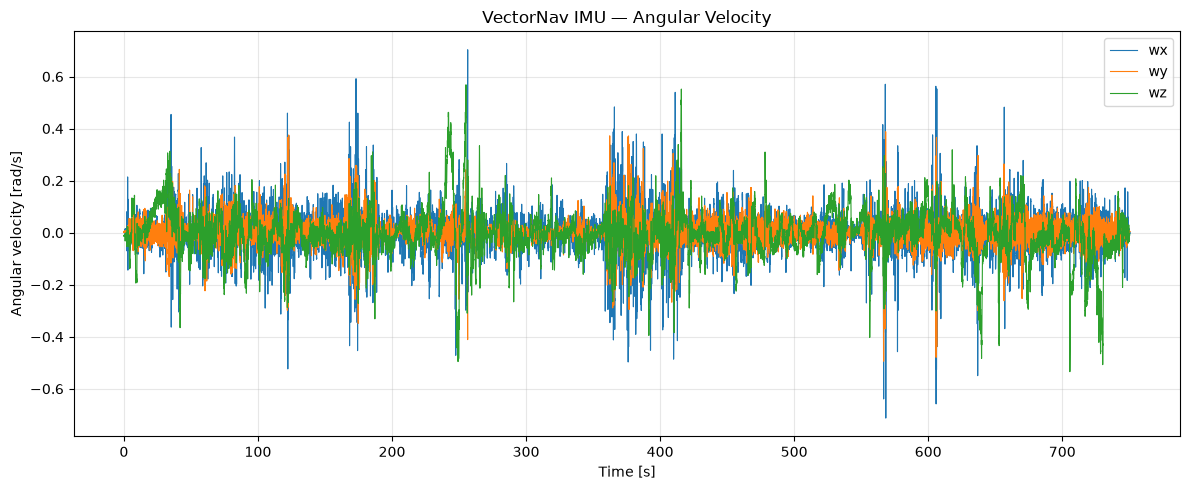

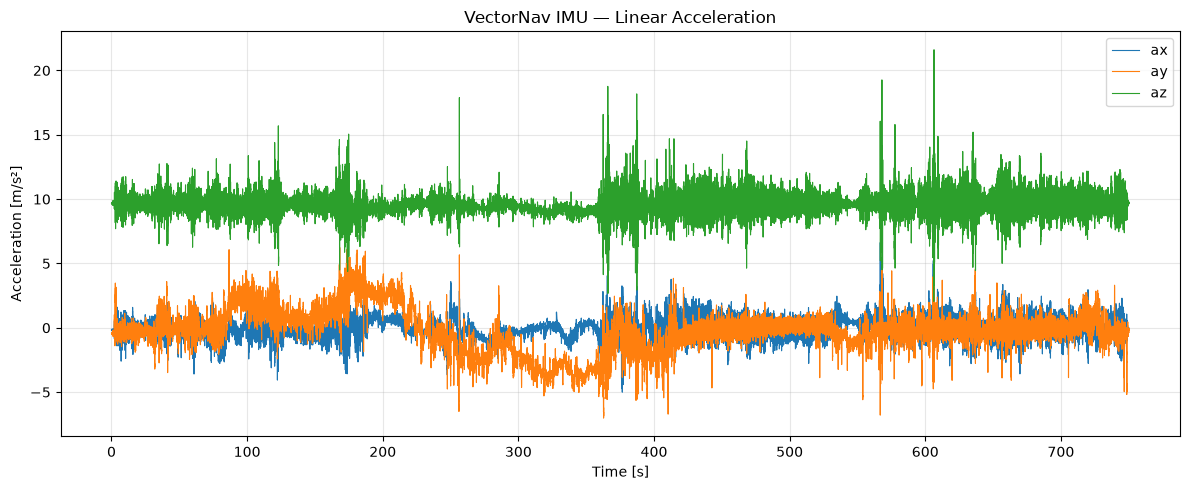


Figures saved:
D:\Autonomous_Forest_Navigation\figures\green_vectornav_gyroscope.png
D:\Autonomous_Forest_Navigation\figures\green_vectornav_acceleration.png


In [20]:
# Visualize VectorNav IMU measurements during the ground-truth interval

import matplotlib.pyplot as plt

# Keep only the part of the IMU stream that overlaps with ground truth
imu_sync = imu[
    (imu["timestamp"] >= gt_start) &
    (imu["timestamp"] <= gt_end)
].copy()

# Relative time starting at 0 seconds
imu_sync["time_s"] = imu_sync["timestamp"] - gt_start

print("SYNCHRONIZED IMU DATA")
print("=" * 60)
print(f"Samples retained : {len(imu_sync):,}")
print(f"Start time       : {imu_sync['time_s'].iloc[0]:.3f} s")
print(f"End time         : {imu_sync['time_s'].iloc[-1]:.3f} s")

# ---------------------------------------------------------
# Gyroscope plot
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(imu_sync["time_s"], imu_sync["wx"], label="wx", linewidth=0.8)
ax.plot(imu_sync["time_s"], imu_sync["wy"], label="wy", linewidth=0.8)
ax.plot(imu_sync["time_s"], imu_sync["wz"], label="wz", linewidth=0.8)

ax.set_title("VectorNav IMU — Angular Velocity")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Angular velocity [rad/s]")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()

gyro_figure = FIGURES_DIR / "green_vectornav_gyroscope.png"

plt.savefig(
    gyro_figure,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# ---------------------------------------------------------
# Accelerometer plot
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(imu_sync["time_s"], imu_sync["ax"], label="ax", linewidth=0.8)
ax.plot(imu_sync["time_s"], imu_sync["ay"], label="ay", linewidth=0.8)
ax.plot(imu_sync["time_s"], imu_sync["az"], label="az", linewidth=0.8)

ax.set_title("VectorNav IMU — Linear Acceleration")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Acceleration [m/s²]")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()

accel_figure = FIGURES_DIR / "green_vectornav_acceleration.png"

plt.savefig(
    accel_figure,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("\nFigures saved:")
print(gyro_figure)
print(accel_figure)

In [21]:
# Load and analyze robot odometry

ODOM_FILE = LOCAL_SESSION_DIR / "odom.csv"

odom = pd.read_csv(ODOM_FILE)

print("ROBOT ODOMETRY ANALYSIS")
print("=" * 70)

print(f"Number of odometry samples : {len(odom):,}")
print(f"Columns                    : {list(odom.columns)}")

# ---------------------------------------------------------
# Determine timestamp scale
# ---------------------------------------------------------

odom_raw_time = odom["t"].median()

odom_timestamp_scale = min(
    possible_scales,
    key=lambda scale: abs(
        np.log10((odom_raw_time / scale) / gt_reference_time)
    )
)

odom["timestamp"] = odom["t"] / odom_timestamp_scale

print(f"\nDetected timestamp scale   : {odom_timestamp_scale:g}")
print(f"First odometry timestamp   : {odom['timestamp'].iloc[0]:.6f}")
print(f"Last odometry timestamp    : {odom['timestamp'].iloc[-1]:.6f}")

# ---------------------------------------------------------
# Timing / sample rate
# ---------------------------------------------------------

odom_dt = np.diff(odom["timestamp"].to_numpy())
odom_valid_dt = odom_dt[odom_dt > 0]

odom_median_dt = np.median(odom_valid_dt)
odom_rate = 1.0 / odom_median_dt

odom_duration = (
    odom["timestamp"].iloc[-1]
    - odom["timestamp"].iloc[0]
)

print("\nTIMING")
print("=" * 70)

print(f"Duration               : {odom_duration:.2f} s")
print(f"Duration               : {odom_duration / 60:.2f} min")
print(f"Median sample interval : {odom_median_dt:.6f} s")
print(f"Estimated sample rate  : {odom_rate:.2f} Hz")
print(f"Non-positive time gaps : {(odom_dt <= 0).sum():,}")

# ---------------------------------------------------------
# Data quality
# ---------------------------------------------------------

print("\nDATA QUALITY")
print("=" * 70)

print(f"Missing values         : {odom.isna().sum().sum():,}")
print(f"Duplicate timestamps   : {odom['t'].duplicated().sum():,}")

# ---------------------------------------------------------
# Position information
# ---------------------------------------------------------

print("\nODOMETRY POSITION RANGE")
print("=" * 70)

for col in ["px", "py", "pz"]:
    print(
        f"{col}: "
        f"{odom[col].min():10.3f} -> "
        f"{odom[col].max():10.3f}"
    )

# Distance travelled according to odometry
odom_positions = odom[["px", "py", "pz"]].to_numpy()

odom_step_distances = np.linalg.norm(
    np.diff(odom_positions, axis=0),
    axis=1
)

odom_distance = odom_step_distances.sum()

print(f"\n3D odometry distance   : {odom_distance:.2f} m")

# ---------------------------------------------------------
# Quaternion check
# ---------------------------------------------------------

quat_cols = ["qx", "qy", "qz", "qw"]

unique_odom_quaternions = (
    odom[quat_cols]
    .drop_duplicates()
)

print("\nORIENTATION")
print("=" * 70)

print(
    f"Unique odometry quaternions : "
    f"{len(unique_odom_quaternions):,}"
)

# ---------------------------------------------------------
# Synchronization with ground truth
# ---------------------------------------------------------

odom_start = odom["timestamp"].iloc[0]
odom_end = odom["timestamp"].iloc[-1]

odom_overlap_start = max(gt_start, odom_start)
odom_overlap_end = min(gt_end, odom_end)

odom_overlap = max(
    0,
    odom_overlap_end - odom_overlap_start
)

print("\nGROUND TRUTH / ODOMETRY SYNCHRONIZATION")
print("=" * 70)

print(f"GT start     : {gt_start:.6f}")
print(f"GT end       : {gt_end:.6f}")
print(f"Odom start   : {odom_start:.6f}")
print(f"Odom end     : {odom_end:.6f}")
print(f"Overlap      : {odom_overlap:.2f} s")
print(f"Overlap      : {odom_overlap / 60:.2f} min")

print("\nFirst 5 odometry samples:")
display(odom.head())

ROBOT ODOMETRY ANALYSIS
Number of odometry samples : 9,790
Columns                    : ['t', 'px', 'py', 'pz', 'qx', 'qy', 'qz', 'qw', 'tlx', 'tly', 'tlz', 'tax', 'tay', 'taz', 'tax.1', 'tay.1', 'taz.1']

Detected timestamp scale   : 1e+06
First odometry timestamp   : 1750951239.107009
Last odometry timestamp    : 1750951989.225227

TIMING
Duration               : 750.12 s
Duration               : 12.50 min
Median sample interval : 0.097752 s
Estimated sample rate  : 10.23 Hz
Non-positive time gaps : 0

DATA QUALITY
Missing values         : 29,370
Duplicate timestamps   : 0

ODOMETRY POSITION RANGE
px:   -289.856 ->     29.719
py:   -126.527 ->    164.576
pz:      0.000 ->      0.000

3D odometry distance   : 826.14 m

ORIENTATION
Unique odometry quaternions : 9,685

GROUND TRUTH / ODOMETRY SYNCHRONIZATION
GT start     : 1750951238.995000
GT end       : 1750951989.295000
Odom start   : 1750951239.107009
Odom end     : 1750951989.225227
Overlap      : 750.12 s
Overlap      : 12.50 min


,t,px,py,pz,qx,qy,qz,qw,tlx,tly,tlz,tax,tay,taz,tax.1,tay.1,taz.1,timestamp
0,1750951239107009,0.0,0.0,0,0,0,0.0,1.0,0.0,0,0,0,0,0.0,NaN,NaN,NaN,1.750951e+09
1,1750951239207009,0.0,0.0,0,0,0,0.0,1.0,0.0,0,0,0,0,0.0,NaN,NaN,NaN,1.750951e+09
2,1750951239259087,0.0,0.0,0,0,0,0.0,1.0,0.0,0,0,0,0,0.0,NaN,NaN,NaN,1.750951e+09
3,1750951239357069,0.0,0.0,0,0,0,0.0,1.0,0.0,0,0,0,0,0.0,NaN,NaN,NaN,1.750951e+09
4,1750951239457069,0.0,0.0,0,0,0,0.0,1.0,0.0,0,0,0,0,0.0,NaN,NaN,NaN,1.750951e+09


ODOMETRY CLEANING
Completely empty columns:
['tax.1', 'tay.1', 'taz.1']

Remaining columns:
['t', 'px', 'py', 'pz', 'qx', 'qy', 'qz', 'qw', 'tlx', 'tly', 'tlz', 'tax', 'tay', 'taz', 'timestamp']

Remaining missing values: 0

SYNCHRONIZED ODOMETRY
Samples retained : 9,790


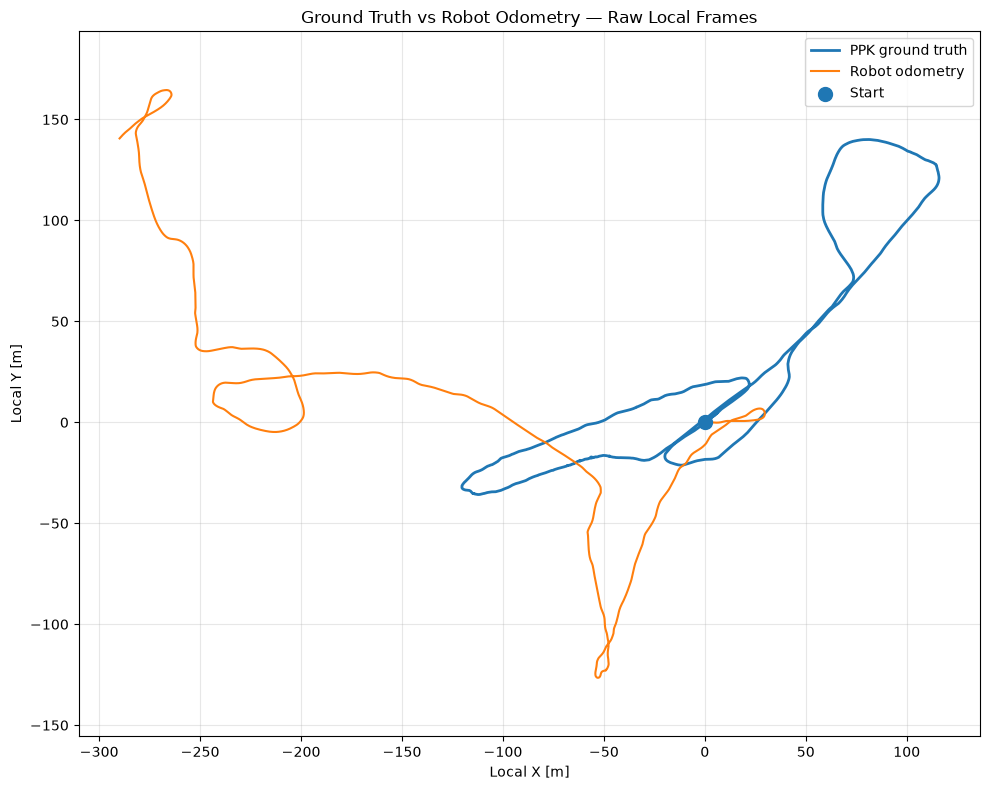


Figure saved to:
D:\Autonomous_Forest_Navigation\figures\green_ground_truth_vs_odometry_raw.png


In [22]:
# Clean odometry data and compare its trajectory with ground truth

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Remove columns that contain no data
# ---------------------------------------------------------

empty_columns = [
    col for col in odom.columns
    if odom[col].isna().all()
]

print("ODOMETRY CLEANING")
print("=" * 70)

print("Completely empty columns:")
print(empty_columns)

odom_clean = odom.drop(columns=empty_columns).copy()

print("\nRemaining columns:")
print(list(odom_clean.columns))

print(
    "\nRemaining missing values:",
    odom_clean.isna().sum().sum()
)


# ---------------------------------------------------------
# 2. Synchronize odometry to the GT time interval
# ---------------------------------------------------------

odom_sync = odom_clean[
    (odom_clean["timestamp"] >= gt_start) &
    (odom_clean["timestamp"] <= gt_end)
].copy()

print("\nSYNCHRONIZED ODOMETRY")
print("=" * 70)

print(f"Samples retained : {len(odom_sync):,}")


# ---------------------------------------------------------
# 3. Express both trajectories relative to their start
# ---------------------------------------------------------

gt_x_local = gt["x"] - gt["x"].iloc[0]
gt_y_local = gt["y"] - gt["y"].iloc[0]

odom_x_local = (
    odom_sync["px"] -
    odom_sync["px"].iloc[0]
)

odom_y_local = (
    odom_sync["py"] -
    odom_sync["py"].iloc[0]
)


# ---------------------------------------------------------
# 4. Plot both coordinate frames
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(
    gt_x_local,
    gt_y_local,
    linewidth=2,
    label="PPK ground truth"
)

ax.plot(
    odom_x_local,
    odom_y_local,
    linewidth=1.5,
    label="Robot odometry"
)

ax.scatter(
    0,
    0,
    s=100,
    marker="o",
    label="Start",
    zorder=5
)

ax.set_title(
    "Ground Truth vs Robot Odometry — Raw Local Frames"
)

ax.set_xlabel("Local X [m]")
ax.set_ylabel("Local Y [m]")

ax.axis("equal")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()

odom_comparison_figure = (
    FIGURES_DIR /
    "green_ground_truth_vs_odometry_raw.png"
)

plt.savefig(
    odom_comparison_figure,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved to:")
print(odom_comparison_figure)

ODOMETRY → GROUND-TRUTH ALIGNMENT
Rotation angle      : -114.729 deg
Translation X       : 255956.020 m
Translation Y       : 5242850.802 m

POSITION ERROR AFTER ALIGNMENT
RMSE                : 93.485 m
Mean error          : 69.321 m
Median error        : 42.893 m
Maximum error       : 257.681 m
Final position error: 226.945 m


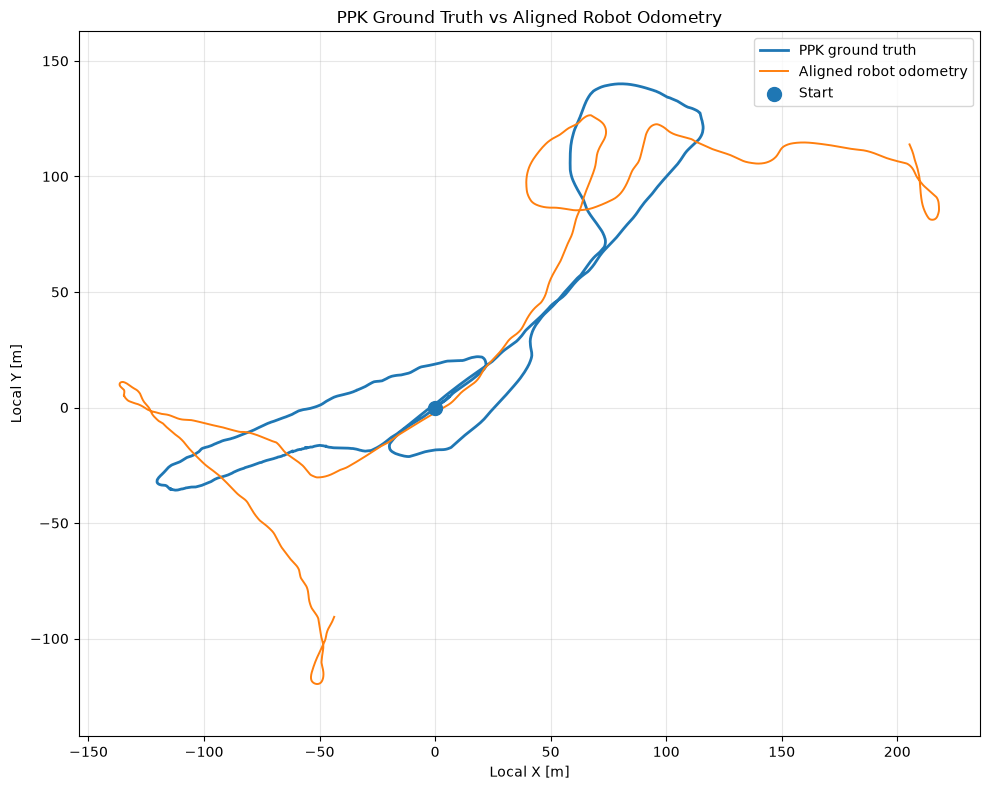


Figure saved to:
D:\Autonomous_Forest_Navigation\figures\green_ground_truth_vs_odometry_aligned.png


In [23]:
# Align the robot odometry coordinate frame with the PPK ground-truth frame

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Use only odometry timestamps inside the GT interval
# ---------------------------------------------------------

odom_align = odom_clean[
    (odom_clean["timestamp"] >= gt["timestamp"].iloc[0]) &
    (odom_clean["timestamp"] <= gt["timestamp"].iloc[-1])
].copy()

odom_times = odom_align["timestamp"].to_numpy()

# ---------------------------------------------------------
# 2. Interpolate GT position at every odometry timestamp
# ---------------------------------------------------------

gt_interp_x = np.interp(
    odom_times,
    gt["timestamp"].to_numpy(),
    gt["x"].to_numpy()
)

gt_interp_y = np.interp(
    odom_times,
    gt["timestamp"].to_numpy(),
    gt["y"].to_numpy()
)

gt_xy_sync = np.column_stack([
    gt_interp_x,
    gt_interp_y
])

odom_xy = odom_align[
    ["px", "py"]
].to_numpy()

# ---------------------------------------------------------
# 3. Estimate rigid 2D transformation using Kabsch
# ---------------------------------------------------------

odom_centroid = odom_xy.mean(axis=0)
gt_centroid = gt_xy_sync.mean(axis=0)

odom_centered = odom_xy - odom_centroid
gt_centered = gt_xy_sync - gt_centroid

H = odom_centered.T @ gt_centered

U, S, Vt = np.linalg.svd(H)

R = Vt.T @ U.T

# Prevent an unwanted reflection
if np.linalg.det(R) < 0:
    Vt[-1, :] *= -1
    R = Vt.T @ U.T

translation = (
    gt_centroid -
    odom_centroid @ R.T
)

# Apply transformation
odom_aligned = (
    odom_xy @ R.T +
    translation
)

# ---------------------------------------------------------
# 4. Calculate alignment error
# ---------------------------------------------------------

position_errors = np.linalg.norm(
    odom_aligned - gt_xy_sync,
    axis=1
)

rmse = np.sqrt(
    np.mean(position_errors ** 2)
)

mean_error = np.mean(position_errors)
median_error = np.median(position_errors)
max_error = np.max(position_errors)

final_error = position_errors[-1]

rotation_angle = np.degrees(
    np.arctan2(
        R[1, 0],
        R[0, 0]
    )
)

print("ODOMETRY → GROUND-TRUTH ALIGNMENT")
print("=" * 65)

print(f"Rotation angle      : {rotation_angle:.3f} deg")
print(f"Translation X       : {translation[0]:.3f} m")
print(f"Translation Y       : {translation[1]:.3f} m")

print("\nPOSITION ERROR AFTER ALIGNMENT")
print("=" * 65)

print(f"RMSE                : {rmse:.3f} m")
print(f"Mean error          : {mean_error:.3f} m")
print(f"Median error        : {median_error:.3f} m")
print(f"Maximum error       : {max_error:.3f} m")
print(f"Final position error: {final_error:.3f} m")

# ---------------------------------------------------------
# 5. Convert to local coordinates for plotting
# ---------------------------------------------------------

reference_origin = gt_xy_sync[0]

gt_plot = (
    gt_xy_sync -
    reference_origin
)

odom_plot = (
    odom_aligned -
    reference_origin
)

# ---------------------------------------------------------
# 6. Plot aligned trajectories
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(
    gt_plot[:, 0],
    gt_plot[:, 1],
    linewidth=2,
    label="PPK ground truth"
)

ax.plot(
    odom_plot[:, 0],
    odom_plot[:, 1],
    linewidth=1.4,
    label="Aligned robot odometry"
)

ax.scatter(
    gt_plot[0, 0],
    gt_plot[0, 1],
    s=100,
    marker="o",
    label="Start",
    zorder=5
)

ax.set_title(
    "PPK Ground Truth vs Aligned Robot Odometry"
)

ax.set_xlabel("Local X [m]")
ax.set_ylabel("Local Y [m]")

ax.axis("equal")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()

aligned_figure = (
    FIGURES_DIR /
    "green_ground_truth_vs_odometry_aligned.png"
)

plt.savefig(
    aligned_figure,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("\nFigure saved to:")
print(aligned_figure)

COORDINATE-FRAME DIAGNOSTIC

Rigid rotation only:
det(R) : 1.000
RMSE   : 93.485 m

Reflection allowed:
det(R) : 1.000
RMSE   : 93.485 m

BEST DIAGNOSTIC RESULT
Transform             : Rigid rotation
Mean error            : 69.321 m
Median error          : 42.893 m
Maximum error         : 257.681 m
Final position error  : 226.945 m


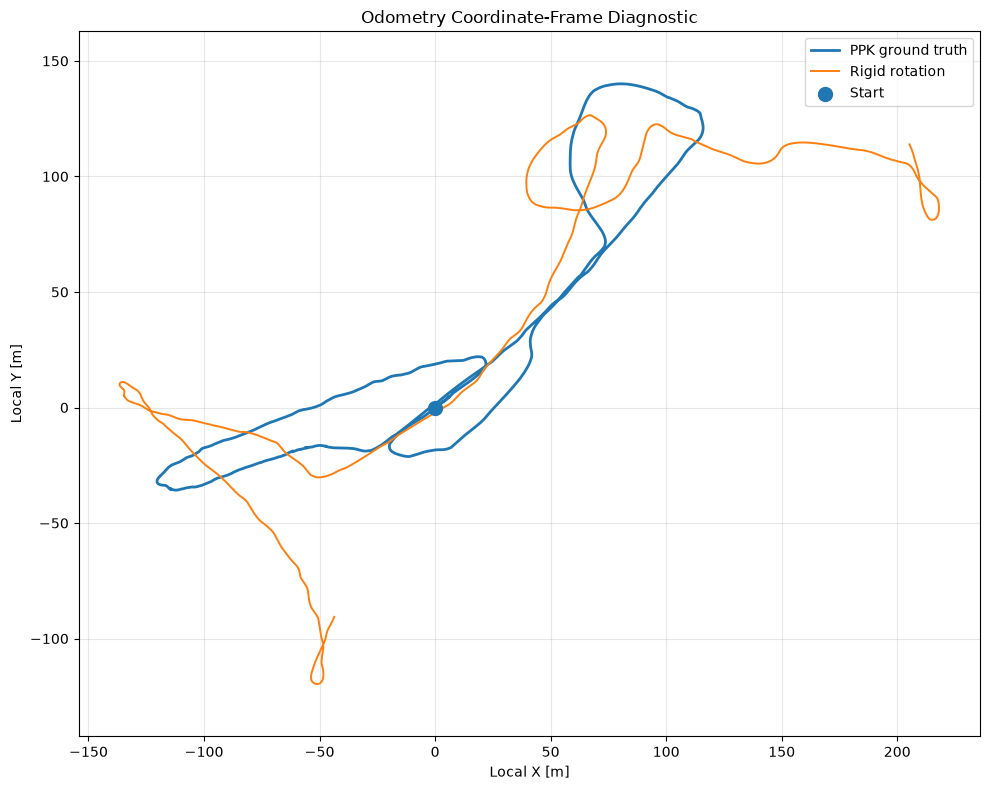

In [24]:
# Diagnose whether the odometry frame differs by rotation only
# or by an axis reflection / handedness change.

import numpy as np
import matplotlib.pyplot as plt


def align_2d(source, target, allow_reflection=False):
    """
    Align source Nx2 points to target Nx2 points
    using an orthogonal 2D transformation + translation.
    """

    source_centroid = source.mean(axis=0)
    target_centroid = target.mean(axis=0)

    source_centered = source - source_centroid
    target_centered = target - target_centroid

    H = source_centered.T @ target_centered

    U, S, Vt = np.linalg.svd(H)

    R = Vt.T @ U.T

    # For a physical rigid-body transform, reflection is not allowed.
    if not allow_reflection and np.linalg.det(R) < 0:
        Vt[-1, :] *= -1
        R = Vt.T @ U.T

    translation = (
        target_centroid -
        source_centroid @ R.T
    )

    aligned = (
        source @ R.T +
        translation
    )

    errors = np.linalg.norm(
        aligned - target,
        axis=1
    )

    rmse = np.sqrt(
        np.mean(errors ** 2)
    )

    return R, translation, aligned, errors, rmse


# ---------------------------------------------------------
# Proper rigid rotation: determinant must be +1
# ---------------------------------------------------------

R_rigid, t_rigid, aligned_rigid, errors_rigid, rmse_rigid = align_2d(
    odom_xy,
    gt_xy_sync,
    allow_reflection=False
)


# ---------------------------------------------------------
# Diagnostic transform: reflection is allowed
# ---------------------------------------------------------

R_free, t_free, aligned_free, errors_free, rmse_free = align_2d(
    odom_xy,
    gt_xy_sync,
    allow_reflection=True
)


print("COORDINATE-FRAME DIAGNOSTIC")
print("=" * 70)

print("\nRigid rotation only:")
print(f"det(R) : {np.linalg.det(R_rigid):.3f}")
print(f"RMSE   : {rmse_rigid:.3f} m")

print("\nReflection allowed:")
print(f"det(R) : {np.linalg.det(R_free):.3f}")
print(f"RMSE   : {rmse_free:.3f} m")


# ---------------------------------------------------------
# Choose lower-error result only for visualization
# ---------------------------------------------------------

if rmse_free < rmse_rigid:
    best_aligned = aligned_free
    best_errors = errors_free
    best_name = "Reflection-allowed diagnostic"
else:
    best_aligned = aligned_rigid
    best_errors = errors_rigid
    best_name = "Rigid rotation"


reference_origin = gt_xy_sync[0]

gt_diag_plot = gt_xy_sync - reference_origin
odom_diag_plot = best_aligned - reference_origin


print("\nBEST DIAGNOSTIC RESULT")
print("=" * 70)

print(f"Transform             : {best_name}")
print(f"Mean error            : {best_errors.mean():.3f} m")
print(f"Median error          : {np.median(best_errors):.3f} m")
print(f"Maximum error         : {best_errors.max():.3f} m")
print(f"Final position error  : {best_errors[-1]:.3f} m")


# ---------------------------------------------------------
# Plot
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(
    gt_diag_plot[:, 0],
    gt_diag_plot[:, 1],
    linewidth=2,
    label="PPK ground truth"
)

ax.plot(
    odom_diag_plot[:, 0],
    odom_diag_plot[:, 1],
    linewidth=1.4,
    label=best_name
)

ax.scatter(
    0,
    0,
    s=100,
    marker="o",
    label="Start",
    zorder=5
)

ax.set_title(
    "Odometry Coordinate-Frame Diagnostic"
)

ax.set_xlabel("Local X [m]")
ax.set_ylabel("Local Y [m]")

ax.axis("equal")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

INITIAL ALIGNMENT
Alignment window : 60.0 s
Samples used     : 769
Initial rotation : 25.750 deg
Initial-fit RMSE : 5.094 m

ODOMETRY DRIFT
Mean error       : 184.096 m
Median error     : 145.019 m
Maximum error    : 405.811 m
Final error      : 331.919 m
Error at  60 s :   11.293 m
Error at 120 s :   65.805 m
Error at 300 s :  135.491 m
Error at 600 s :  327.623 m
Error at 750 s :  331.919 m


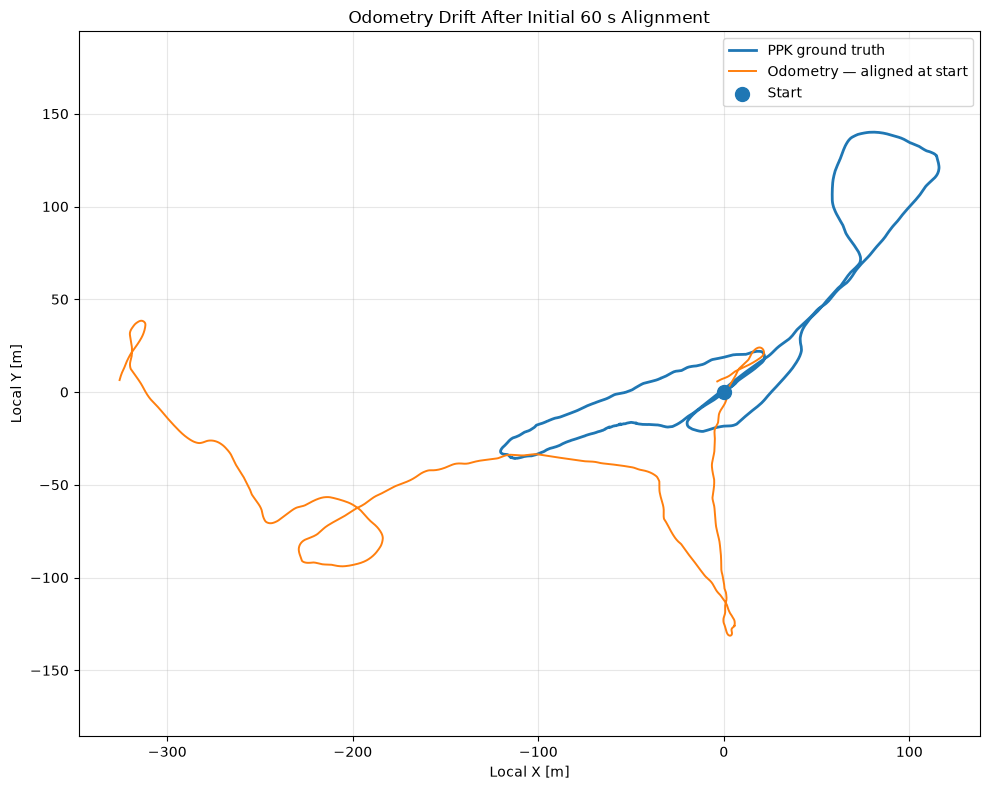

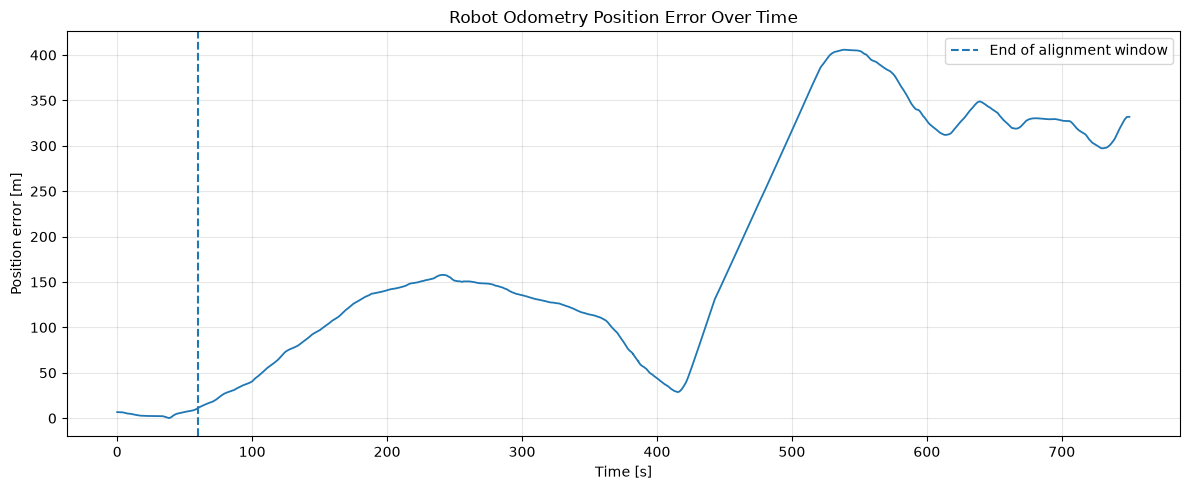


Figures saved:
D:\Autonomous_Forest_Navigation\figures\green_odometry_drift_trajectory.png
D:\Autonomous_Forest_Navigation\figures\green_odometry_drift_error.png


In [25]:
# Measure odometry drift after aligning only the beginning of the run

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Relative time for synchronized odometry
# ---------------------------------------------------------

time_rel = odom_times - odom_times[0]

# Use only the first 60 seconds to estimate
# the initial coordinate-frame transformation.
ALIGNMENT_WINDOW_SEC = 60.0

initial_mask = time_rel <= ALIGNMENT_WINDOW_SEC

odom_initial = odom_xy[initial_mask]
gt_initial = gt_xy_sync[initial_mask]

print("INITIAL ALIGNMENT")
print("=" * 70)

print(f"Alignment window : {ALIGNMENT_WINDOW_SEC:.1f} s")
print(f"Samples used     : {initial_mask.sum():,}")

# ---------------------------------------------------------
# 2. Estimate rigid transform using ONLY initial segment
# ---------------------------------------------------------

R_initial, t_initial, _, _, initial_rmse = align_2d(
    odom_initial,
    gt_initial,
    allow_reflection=False
)

rotation_initial = np.degrees(
    np.arctan2(
        R_initial[1, 0],
        R_initial[0, 0]
    )
)

print(f"Initial rotation : {rotation_initial:.3f} deg")
print(f"Initial-fit RMSE : {initial_rmse:.3f} m")

# ---------------------------------------------------------
# 3. Apply that SAME transform to the full trajectory
# ---------------------------------------------------------

odom_initial_aligned = (
    odom_xy @ R_initial.T +
    t_initial
)

# ---------------------------------------------------------
# 4. Compute position error over entire recording
# ---------------------------------------------------------

drift_error = np.linalg.norm(
    odom_initial_aligned - gt_xy_sync,
    axis=1
)

print("\nODOMETRY DRIFT")
print("=" * 70)

print(f"Mean error       : {drift_error.mean():.3f} m")
print(f"Median error     : {np.median(drift_error):.3f} m")
print(f"Maximum error    : {drift_error.max():.3f} m")
print(f"Final error      : {drift_error[-1]:.3f} m")

# Error at useful time checkpoints
for checkpoint in [60, 120, 300, 600, 750]:

    idx = np.argmin(
        np.abs(time_rel - checkpoint)
    )

    print(
        f"Error at {checkpoint:3d} s : "
        f"{drift_error[idx]:8.3f} m"
    )

# ---------------------------------------------------------
# 5. Local coordinates for trajectory plot
# ---------------------------------------------------------

origin = gt_xy_sync[0]

gt_local = gt_xy_sync - origin
odom_local = odom_initial_aligned - origin

# ---------------------------------------------------------
# 6. Trajectory plot
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(
    gt_local[:, 0],
    gt_local[:, 1],
    linewidth=2,
    label="PPK ground truth"
)

ax.plot(
    odom_local[:, 0],
    odom_local[:, 1],
    linewidth=1.4,
    label="Odometry — aligned at start"
)

ax.scatter(
    0,
    0,
    s=100,
    marker="o",
    label="Start",
    zorder=5
)

ax.set_title(
    "Odometry Drift After Initial 60 s Alignment"
)

ax.set_xlabel("Local X [m]")
ax.set_ylabel("Local Y [m]")

ax.axis("equal")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()

drift_trajectory_figure = (
    FIGURES_DIR /
    "green_odometry_drift_trajectory.png"
)

plt.savefig(
    drift_trajectory_figure,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# ---------------------------------------------------------
# 7. Error-vs-time plot
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    time_rel,
    drift_error,
    linewidth=1.3
)

ax.axvline(
    ALIGNMENT_WINDOW_SEC,
    linestyle="--",
    label="End of alignment window"
)

ax.set_title(
    "Robot Odometry Position Error Over Time"
)

ax.set_xlabel("Time [s]")
ax.set_ylabel("Position error [m]")

ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()

drift_error_figure = (
    FIGURES_DIR /
    "green_odometry_drift_error.png"
)

plt.savefig(
    drift_error_figure,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("\nFigures saved:")
print(drift_trajectory_figure)
print(drift_error_figure)

IMU / ODOMETRY MOTION CONSISTENCY
Odometry samples used : 9,790

GYROSCOPE / ODOMETRY CORRELATION
Odometry taz vs IMU wx: -0.0263
Odometry taz vs IMU wy: +0.0427
Odometry taz vs IMU wz: +0.8487

BEST MATCH
IMU axis              : wz
Correlation           : +0.8487
Visualization sign    : +1

ODOMETRY SPEED
Mean speed            : 1.103 m/s
Median speed          : 1.031 m/s
Maximum speed         : 2.604 m/s


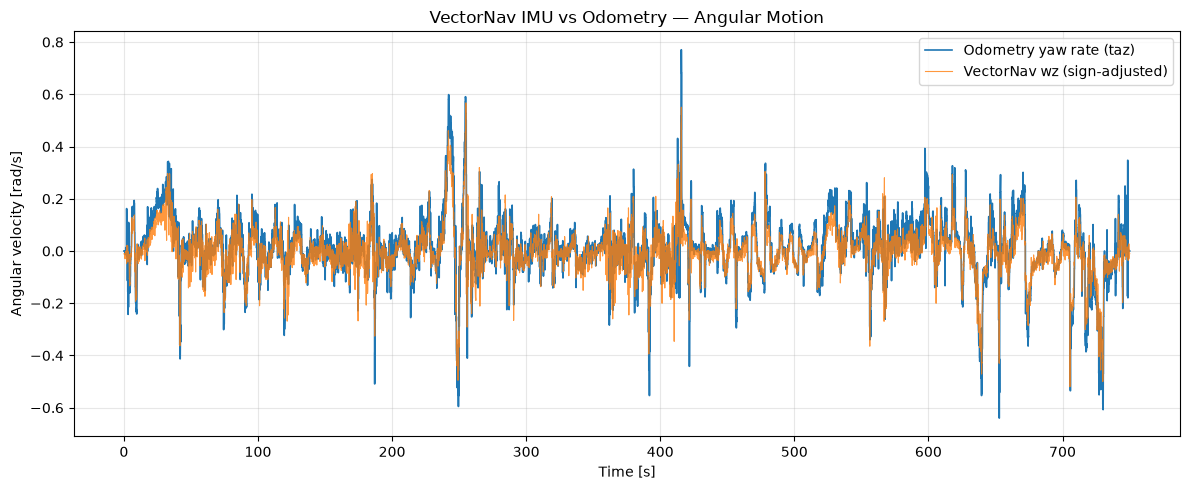

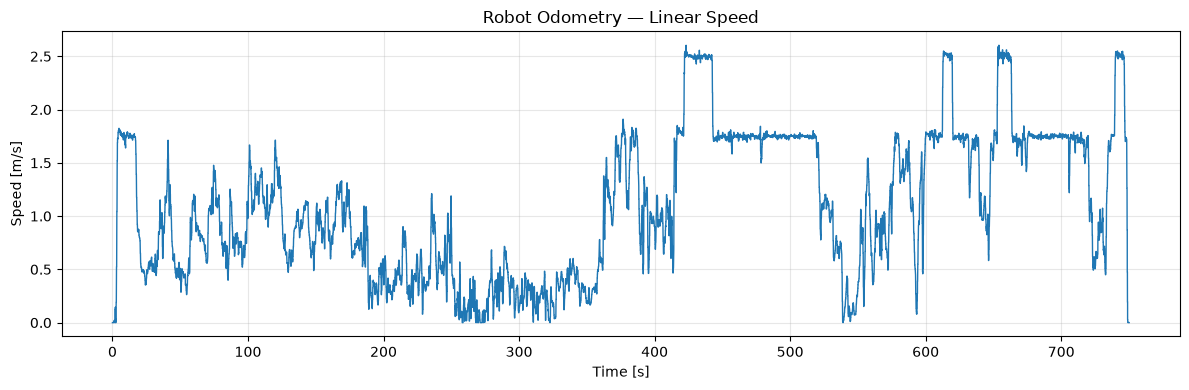


Figures saved:
D:\Autonomous_Forest_Navigation\figures\green_imu_vs_odometry_yaw_rate.png
D:\Autonomous_Forest_Navigation\figures\green_odometry_speed.png


In [26]:
# Compare VectorNav angular velocity with robot odometry angular velocity
# and inspect the odometry motion signals.

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Keep odometry samples inside IMU time range
# ---------------------------------------------------------

motion_odom = odom_clean[
    (odom_clean["timestamp"] >= imu["timestamp"].iloc[0]) &
    (odom_clean["timestamp"] <= imu["timestamp"].iloc[-1])
].copy()

motion_times = motion_odom["timestamp"].to_numpy()

print("IMU / ODOMETRY MOTION CONSISTENCY")
print("=" * 70)

print(f"Odometry samples used : {len(motion_odom):,}")

# ---------------------------------------------------------
# 2. Interpolate IMU gyro axes to odometry timestamps
# ---------------------------------------------------------

imu_time = imu["timestamp"].to_numpy()

gyro_interp = {}

for axis in ["wx", "wy", "wz"]:
    gyro_interp[axis] = np.interp(
        motion_times,
        imu_time,
        imu[axis].to_numpy()
    )

# Odometry angular velocity about Z
odom_yaw_rate = motion_odom["taz"].to_numpy()

# ---------------------------------------------------------
# 3. Correlation between odometry yaw-rate and each IMU axis
# ---------------------------------------------------------

correlations = {}

for axis in ["wx", "wy", "wz"]:

    corr = np.corrcoef(
        odom_yaw_rate,
        gyro_interp[axis]
    )[0, 1]

    correlations[axis] = corr


print("\nGYROSCOPE / ODOMETRY CORRELATION")
print("=" * 70)

for axis, corr in correlations.items():
    print(
        f"Odometry taz vs IMU {axis}: "
        f"{corr:+.4f}"
    )

# Choose the IMU axis with strongest absolute correlation
best_axis = max(
    correlations,
    key=lambda axis: abs(correlations[axis])
)

best_corr = correlations[best_axis]

# Adjust sign only for visualization
sign_factor = 1.0 if best_corr >= 0 else -1.0

imu_yaw_rate = (
    gyro_interp[best_axis] *
    sign_factor
)

print("\nBEST MATCH")
print("=" * 70)

print(f"IMU axis              : {best_axis}")
print(f"Correlation           : {best_corr:+.4f}")
print(f"Visualization sign    : {sign_factor:+.0f}")


# ---------------------------------------------------------
# 4. Odometry speed
# ---------------------------------------------------------

linear_speed = np.sqrt(
    motion_odom["tlx"].to_numpy() ** 2 +
    motion_odom["tly"].to_numpy() ** 2 +
    motion_odom["tlz"].to_numpy() ** 2
)

print("\nODOMETRY SPEED")
print("=" * 70)

print(f"Mean speed            : {linear_speed.mean():.3f} m/s")
print(f"Median speed          : {np.median(linear_speed):.3f} m/s")
print(f"Maximum speed         : {linear_speed.max():.3f} m/s")


# ---------------------------------------------------------
# 5. Relative time
# ---------------------------------------------------------

motion_time_rel = (
    motion_times -
    motion_times[0]
)

# ---------------------------------------------------------
# 6. Plot yaw-rate comparison
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    motion_time_rel,
    odom_yaw_rate,
    linewidth=1.2,
    label="Odometry yaw rate (taz)"
)

ax.plot(
    motion_time_rel,
    imu_yaw_rate,
    linewidth=0.8,
    alpha=0.8,
    label=f"VectorNav {best_axis} (sign-adjusted)"
)

ax.set_title(
    "VectorNav IMU vs Odometry — Angular Motion"
)

ax.set_xlabel("Time [s]")
ax.set_ylabel("Angular velocity [rad/s]")

ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()

motion_figure = (
    FIGURES_DIR /
    "green_imu_vs_odometry_yaw_rate.png"
)

plt.savefig(
    motion_figure,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ---------------------------------------------------------
# 7. Plot robot speed
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    motion_time_rel,
    linear_speed,
    linewidth=1
)

ax.set_title(
    "Robot Odometry — Linear Speed"
)

ax.set_xlabel("Time [s]")
ax.set_ylabel("Speed [m/s]")

ax.grid(True, alpha=0.3)

plt.tight_layout()

speed_figure = (
    FIGURES_DIR /
    "green_odometry_speed.png"
)

plt.savefig(
    speed_figure,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


print("\nFigures saved:")
print(motion_figure)
print(speed_figure)

In [27]:
# Inspect metadata files for possible GNSS / positioning information

METADATA_PREFIX = SELECTED_SESSION + "metadata/"

metadata_objects = []

paginator = s3.get_paginator("list_objects_v2")

for page in paginator.paginate(
    Bucket=BUCKET,
    Prefix=METADATA_PREFIX
):
    for obj in page.get("Contents", []):
        key = obj["Key"]

        if key.endswith("/"):
            continue

        relative_name = key.replace(
            METADATA_PREFIX,
            ""
        )

        size_kb = obj["Size"] / 1024

        metadata_objects.append(
            (relative_name, size_kb, key)
        )


print("GREEN SESSION — METADATA FILES")
print("=" * 80)

print(
    f"Number of files : "
    f"{len(metadata_objects)}\n"
)

for relative_name, size_kb, _ in metadata_objects:
    print(
        f"{relative_name:55s} "
        f"{size_kb:10.2f} KB"
    )

GREEN SESSION — METADATA FILES
Number of files : 15

basler_metadata.csv                                         401.97 KB
battery_logs.csv                                            620.51 KB
cmd_velocity.csv                                           2488.37 KB
cmd_velocity_left.csv                                      1277.35 KB
cmd_velocity_right.csv                                     1256.95 KB
current_left.csv                                             17.27 KB
current_right.csv                                            17.23 KB
emlid_metadata.csv                                          703.14 KB
meteo_data.csv                                                0.00 KB
velocity_left.csv                                           103.08 KB
velocity_right.csv                                          102.95 KB
vn100_pressure.csv                                         5081.86 KB
vn100_temperature.csv                                      5169.80 KB
voltage_left.csv                     

In [28]:
# Investigate Emlid Reach M2 / GNSS-related data in the selected session
# This only searches filenames and previews a few KB.

from io import StringIO

# ---------------------------------------------------------
# 1. Search the entire session for positioning-related names
# ---------------------------------------------------------

position_terms = [
    "emlid",
    "reach",
    "nmea",
    "rtk",
    "ubx",
    "navsat",
    "fix"
]

position_matches = []

paginator = s3.get_paginator("list_objects_v2")

for page in paginator.paginate(
    Bucket=BUCKET,
    Prefix=SELECTED_SESSION
):
    for obj in page.get("Contents", []):
        key = obj["Key"]
        key_lower = key.lower()

        if any(term in key_lower for term in position_terms):
            position_matches.append(
                (
                    key.replace(SELECTED_SESSION, ""),
                    obj["Size"] / 1024,
                    key
                )
            )

print("EMLID / GNSS FILE SEARCH")
print("=" * 85)

if position_matches:
    for relative_name, size_kb, _ in position_matches:
        print(
            f"{relative_name:60s} "
            f"{size_kb:10.2f} KB"
        )
else:
    print("No Emlid / GNSS-related filenames found.")


# ---------------------------------------------------------
# 2. Preview emlid_metadata.csv
# ---------------------------------------------------------

EMLID_METADATA_KEY = (
    SELECTED_SESSION +
    "metadata/emlid_metadata.csv"
)

obj = s3.get_object(
    Bucket=BUCKET,
    Key=EMLID_METADATA_KEY,
    Range="bytes=0-16383"
)

emlid_preview = (
    obj["Body"]
    .read()
    .decode("utf-8", errors="replace")
)

emlid_lines = emlid_preview.splitlines()

print("\n\nEMLID METADATA PREVIEW")
print("=" * 85)

for line in emlid_lines[:8]:
    print(line)

EMLID / GNSS FILE SEARCH
metadata/emlid_metadata.csv                                      703.14 KB


EMLID METADATA PREVIEW
timestamp,front_solution,front_ns,front_age,front_ratio,left_solution,left_ns,left_age,left_ratio,right_solution,right_ns,right_age,right_ratio
1750951238994000,,,,,fix,19,0.0,104.6,,,,
1750951238995000,fix,20,0.0,84.8,,,,,fix,19,0.0,154.8
1750951239094000,,,,,fix,19,0.1,104.8,,,,
1750951239095000,fix,20,0.1,85.6,,,,,fix,19,0.1,167.0
1750951239194000,,,,,fix,19,0.0,104.9,,,,
1750951239195000,fix,20,0.0,86.4,,,,,fix,19,0.0,167.2
1750951239294000,,,,,fix,19,0.1,105.1,,,,


In [29]:
# Download and analyze Emlid GNSS / RTK solution-quality metadata

EMLID_FILE = LOCAL_SESSION_DIR / "emlid_metadata.csv"

s3.download_file(
    BUCKET,
    EMLID_METADATA_KEY,
    str(EMLID_FILE)
)

emlid = pd.read_csv(EMLID_FILE)

print("EMLID GNSS QUALITY ANALYSIS")
print("=" * 75)

print(f"Rows    : {len(emlid):,}")
print(f"Columns : {list(emlid.columns)}")

# ---------------------------------------------------------
# Convert timestamp from microseconds to seconds
# ---------------------------------------------------------

emlid["timestamp_s"] = emlid["timestamp"] / 1e6

print("\nTIMING")
print("=" * 75)

print(
    f"Start : {emlid['timestamp_s'].iloc[0]:.6f}"
)

print(
    f"End   : {emlid['timestamp_s'].iloc[-1]:.6f}"
)

print(
    f"Duration : "
    f"{emlid['timestamp_s'].iloc[-1] - emlid['timestamp_s'].iloc[0]:.2f} s"
)

# ---------------------------------------------------------
# Inspect each of the three GNSS receivers
# ---------------------------------------------------------

receivers = ["front", "left", "right"]

for receiver in receivers:

    solution_col = f"{receiver}_solution"
    ns_col = f"{receiver}_ns"
    age_col = f"{receiver}_age"
    ratio_col = f"{receiver}_ratio"

    print(f"\n{receiver.upper()} RECEIVER")
    print("=" * 75)

    solution_rows = emlid[
        emlid[solution_col].notna()
    ].copy()

    print(
        f"Solution updates : "
        f"{len(solution_rows):,}"
    )

    if len(solution_rows) > 0:

        print("\nSolution states:")

        print(
            solution_rows[solution_col]
            .value_counts(dropna=False)
            .to_string()
        )

        ns_values = solution_rows[ns_col].dropna()

        if len(ns_values) > 0:

            print(
                f"\nSatellites — mean   : "
                f"{ns_values.mean():.2f}"
            )

            print(
                f"Satellites — median : "
                f"{ns_values.median():.2f}"
            )

            print(
                f"Satellites — min    : "
                f"{ns_values.min():.0f}"
            )

            print(
                f"Satellites — max    : "
                f"{ns_values.max():.0f}"
            )

        ratio_values = solution_rows[ratio_col].dropna()

        if len(ratio_values) > 0:

            print(
                f"RTK ratio — median  : "
                f"{ratio_values.median():.2f}"
            )

            print(
                f"RTK ratio — max     : "
                f"{ratio_values.max():.2f}"
            )

print("\nSaved to:")
print(EMLID_FILE)

EMLID GNSS QUALITY ANALYSIS
Rows    : 15,008
Columns : ['timestamp', 'front_solution', 'front_ns', 'front_age', 'front_ratio', 'left_solution', 'left_ns', 'left_age', 'left_ratio', 'right_solution', 'right_ns', 'right_age', 'right_ratio']

TIMING
Start : 1750951238.994000
End   : 1750951989.295000
Duration : 750.30 s

FRONT RECEIVER
Solution updates : 7,504

Solution states:
front_solution
fix       7279
float      166
single      59

Satellites — mean   : 18.00
Satellites — median : 18.00
Satellites — min    : 0
Satellites — max    : 27
RTK ratio — median  : 28.70
RTK ratio — max     : 999.90

LEFT RECEIVER
Solution updates : 7,504

Solution states:
left_solution
fix       7249
float      205
single      50

Satellites — mean   : 17.24
Satellites — median : 17.00
Satellites — min    : 0
Satellites — max    : 25
RTK ratio — median  : 23.70
RTK ratio — max     : 999.90

RIGHT RECEIVER
Solution updates : 7,503

Solution states:
right_solution
fix       7249
single     129
float      125


PRIMARY GNSS RECEIVER — FRONT EMLID
Total solution updates : 7,504

fix     :  7279 ( 97.00 %)
float   :   166 (  2.21 %)
single  :    59 (  0.79 %)


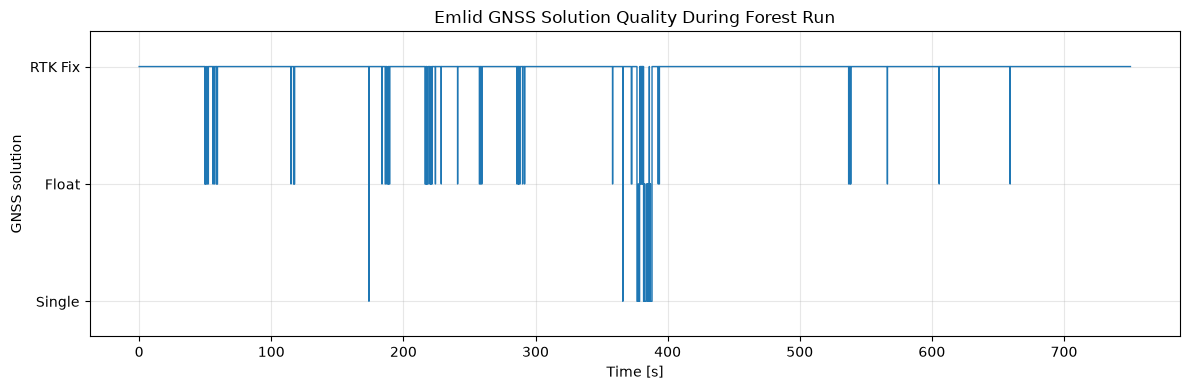

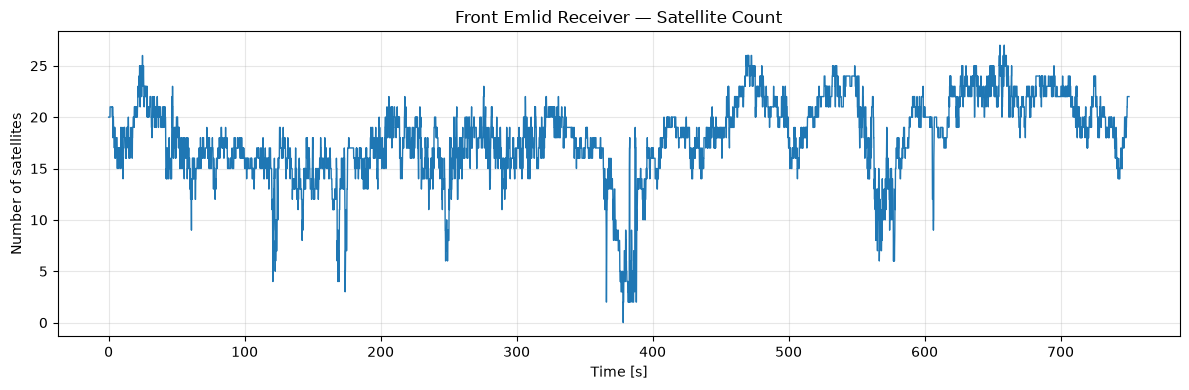


Figures saved:
D:\Autonomous_Forest_Navigation\figures\green_emlid_gnss_quality.png
D:\Autonomous_Forest_Navigation\figures\green_emlid_satellite_count.png


In [30]:
# Analyze and visualize real Emlid GNSS quality over time

import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Use the FRONT receiver as our primary GNSS-quality source
# ---------------------------------------------------------

gnss_quality = emlid[
    emlid["front_solution"].notna()
].copy()

gnss_quality["time_s"] = (
    gnss_quality["timestamp_s"] -
    gnss_quality["timestamp_s"].iloc[0]
)

# ---------------------------------------------------------
# 2. Calculate solution-state percentages
# ---------------------------------------------------------

state_counts = (
    gnss_quality["front_solution"]
    .value_counts()
)

total_updates = len(gnss_quality)

print("PRIMARY GNSS RECEIVER — FRONT EMLID")
print("=" * 70)

print(f"Total solution updates : {total_updates:,}")
print()

for state in ["fix", "float", "single"]:
    
    count = state_counts.get(state, 0)
    percentage = 100 * count / total_updates
    
    print(
        f"{state:8s}: "
        f"{count:5d} "
        f"({percentage:6.2f} %)"
    )

# ---------------------------------------------------------
# 3. Convert solution states to numeric quality levels
# ---------------------------------------------------------

solution_map = {
    "single": 1,
    "float": 2,
    "fix": 3
}

gnss_quality["quality_level"] = (
    gnss_quality["front_solution"]
    .map(solution_map)
)

# ---------------------------------------------------------
# 4. Plot GNSS solution quality
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 4))

ax.step(
    gnss_quality["time_s"],
    gnss_quality["quality_level"],
    where="post",
    linewidth=1
)

ax.set_title(
    "Emlid GNSS Solution Quality During Forest Run"
)

ax.set_xlabel("Time [s]")
ax.set_ylabel("GNSS solution")

ax.set_yticks(
    [1, 2, 3],
    labels=[
        "Single",
        "Float",
        "RTK Fix"
    ]
)

ax.set_ylim(0.7, 3.3)

ax.grid(True, alpha=0.3)

plt.tight_layout()

gnss_quality_figure = (
    FIGURES_DIR /
    "green_emlid_gnss_quality.png"
)

plt.savefig(
    gnss_quality_figure,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

# ---------------------------------------------------------
# 5. Plot satellite count
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(
    gnss_quality["time_s"],
    gnss_quality["front_ns"],
    linewidth=1
)

ax.set_title(
    "Front Emlid Receiver — Satellite Count"
)

ax.set_xlabel("Time [s]")
ax.set_ylabel("Number of satellites")

ax.grid(True, alpha=0.3)

plt.tight_layout()

satellite_figure = (
    FIGURES_DIR /
    "green_emlid_satellite_count.png"
)

plt.savefig(
    satellite_figure,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print("\nFigures saved:")
print(gnss_quality_figure)
print(satellite_figure)

PPK-DERIVED GNSS MEASUREMENT STREAM
Total GNSS updates   : 7,504
Available updates    : 7,458
GNSS dropouts        : 46

QUALITY-DEPENDENT NOISE MODEL
fix      | samples:  7279 | mean position error:  0.634 m
float    | samples:   166 | mean position error:  4.013 m
single   | samples:    13 | mean position error:  9.491 m

OVERALL
GNSS measurement RMSE : 1.092 m


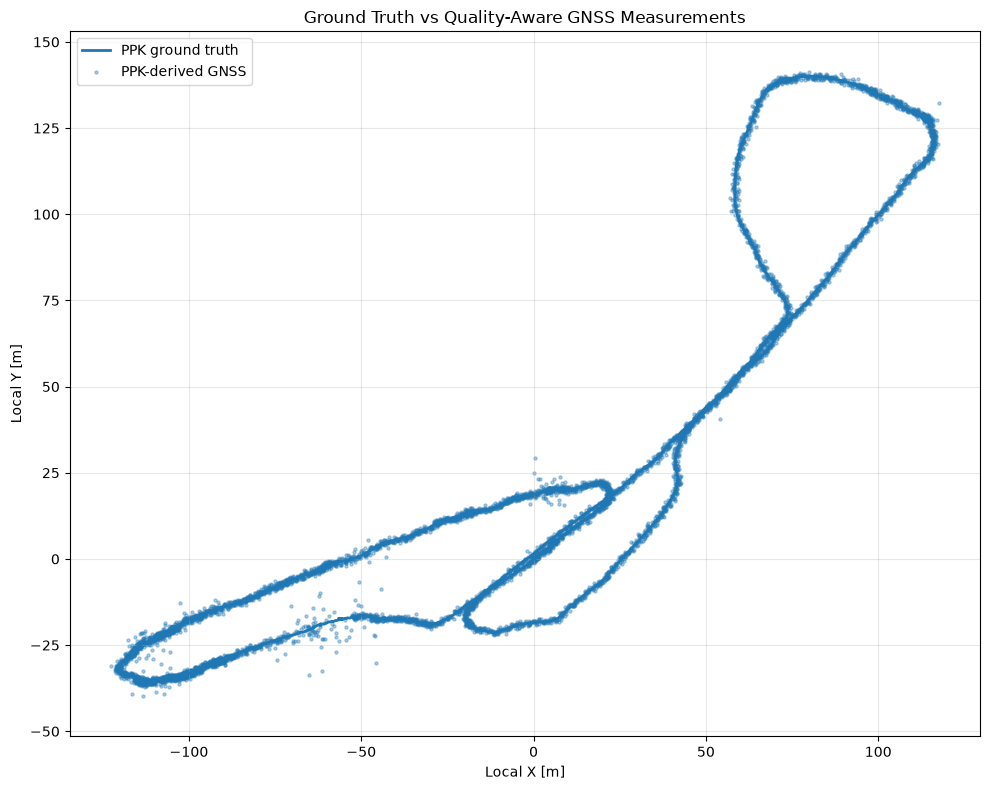

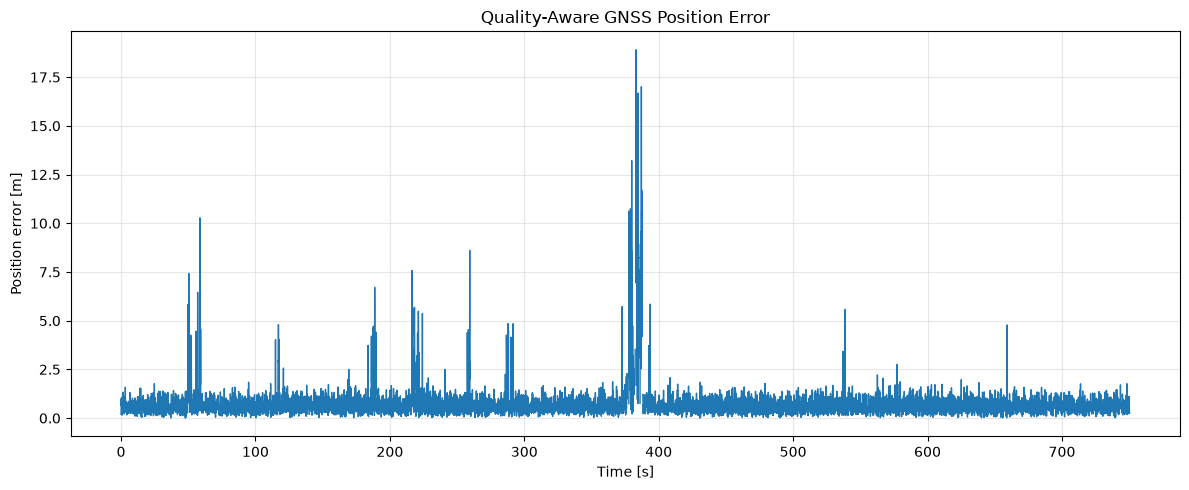


Figures saved:
D:\Autonomous_Forest_Navigation\figures\green_simulated_gnss_trajectory.png
D:\Autonomous_Forest_Navigation\figures\green_simulated_gnss_error.png


In [31]:
# Create reproducible GNSS measurements from PPK reference positions
# using the REAL Emlid solution-quality states recorded during the run.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Ground truth in local coordinates
# ---------------------------------------------------------

gt_gnss = gt[
    ["timestamp", "x", "y"]
].copy()

gt_gnss["gt_x"] = (
    gt_gnss["x"] -
    gt_gnss["x"].iloc[0]
)

gt_gnss["gt_y"] = (
    gt_gnss["y"] -
    gt_gnss["y"].iloc[0]
)

gt_gnss = gt_gnss[
    ["timestamp", "gt_x", "gt_y"]
].sort_values("timestamp")


# ---------------------------------------------------------
# 2. Front Emlid quality measurements
# ---------------------------------------------------------

gnss = emlid[
    emlid["front_solution"].notna()
][
    [
        "timestamp_s",
        "front_solution",
        "front_ns",
        "front_ratio"
    ]
].copy()

gnss = gnss.rename(
    columns={
        "timestamp_s": "timestamp",
        "front_solution": "solution",
        "front_ns": "satellites",
        "front_ratio": "rtk_ratio"
    }
)

gnss = gnss.sort_values("timestamp")


# ---------------------------------------------------------
# 3. Match each Emlid update with nearest PPK reference pose
# ---------------------------------------------------------

gnss = pd.merge_asof(
    gnss,
    gt_gnss,
    on="timestamp",
    direction="nearest",
    tolerance=0.06
)

# Remove any measurement that could not be matched
gnss = gnss.dropna(
    subset=["gt_x", "gt_y"]
).reset_index(drop=True)


# ---------------------------------------------------------
# 4. Define GNSS noise according to REAL solution state
#
# These standard deviations are MODEL assumptions.
# They are not claimed to be measured Emlid errors.
# ---------------------------------------------------------

sigma_map = {
    "fix": 0.50,      # high-quality RTK
    "float": 2.50,    # degraded RTK
    "single": 7.00    # standalone GNSS
}

gnss["sigma_m"] = (
    gnss["solution"]
    .map(sigma_map)
)

# Further reduce confidence when very few satellites are visible
low_satellite_mask = (
    gnss["satellites"] < 8
)

gnss.loc[
    low_satellite_mask,
    "sigma_m"
] *= 2.0


# ---------------------------------------------------------
# 5. Treat extremely poor satellite availability as dropout
# ---------------------------------------------------------

gnss["available"] = (
    gnss["satellites"] >= 4
)


# ---------------------------------------------------------
# 6. Add reproducible Gaussian position noise
# ---------------------------------------------------------

rng = np.random.default_rng(42)

noise_x = rng.normal(
    loc=0.0,
    scale=gnss["sigma_m"].to_numpy()
)

noise_y = rng.normal(
    loc=0.0,
    scale=gnss["sigma_m"].to_numpy()
)

gnss["gnss_x"] = (
    gnss["gt_x"] +
    noise_x
)

gnss["gnss_y"] = (
    gnss["gt_y"] +
    noise_y
)

# Mark complete GNSS dropouts as unavailable
gnss.loc[
    ~gnss["available"],
    ["gnss_x", "gnss_y"]
] = np.nan


# ---------------------------------------------------------
# 7. Measurement error
# ---------------------------------------------------------

gnss["measurement_error"] = np.sqrt(
    (gnss["gnss_x"] - gnss["gt_x"]) ** 2 +
    (gnss["gnss_y"] - gnss["gt_y"]) ** 2
)


# ---------------------------------------------------------
# 8. Summary
# ---------------------------------------------------------

print("PPK-DERIVED GNSS MEASUREMENT STREAM")
print("=" * 72)

print(f"Total GNSS updates   : {len(gnss):,}")
print(
    f"Available updates    : "
    f"{gnss['available'].sum():,}"
)

print(
    f"GNSS dropouts        : "
    f"{(~gnss['available']).sum():,}"
)

print("\nQUALITY-DEPENDENT NOISE MODEL")
print("=" * 72)

for state in ["fix", "float", "single"]:

    subset = gnss[
        (gnss["solution"] == state) &
        gnss["available"]
    ]

    if len(subset) == 0:
        continue

    print(
        f"{state:8s} | "
        f"samples: {len(subset):5d} | "
        f"mean position error: "
        f"{subset['measurement_error'].mean():6.3f} m"
    )


valid_measurements = gnss[
    gnss["available"]
]

gnss_rmse = np.sqrt(
    np.mean(
        valid_measurements["measurement_error"] ** 2
    )
)

print("\nOVERALL")
print("=" * 72)

print(
    f"GNSS measurement RMSE : "
    f"{gnss_rmse:.3f} m"
)


# ---------------------------------------------------------
# 9. Plot GNSS trajectory vs PPK reference
# ---------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 8))

ax.plot(
    gt_gnss["gt_x"],
    gt_gnss["gt_y"],
    linewidth=2,
    label="PPK ground truth"
)

ax.scatter(
    valid_measurements["gnss_x"],
    valid_measurements["gnss_y"],
    s=5,
    alpha=0.35,
    label="PPK-derived GNSS"
)

ax.set_title(
    "Ground Truth vs Quality-Aware GNSS Measurements"
)

ax.set_xlabel("Local X [m]")
ax.set_ylabel("Local Y [m]")

ax.axis("equal")
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()

gnss_trajectory_figure = (
    FIGURES_DIR /
    "green_simulated_gnss_trajectory.png"
)

plt.savefig(
    gnss_trajectory_figure,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


# ---------------------------------------------------------
# 10. GNSS error over time
# ---------------------------------------------------------

gnss["time_s"] = (
    gnss["timestamp"] -
    gnss["timestamp"].iloc[0]
)

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(
    gnss["time_s"],
    gnss["measurement_error"],
    linewidth=1
)

ax.set_title(
    "Quality-Aware GNSS Position Error"
)

ax.set_xlabel("Time [s]")
ax.set_ylabel("Position error [m]")

ax.grid(True, alpha=0.3)

plt.tight_layout()

gnss_error_figure = (
    FIGURES_DIR /
    "green_simulated_gnss_error.png"
)

plt.savefig(
    gnss_error_figure,
    dpi=200,
    bbox_inches="tight"
)

plt.show()


print("\nFigures saved:")
print(gnss_trajectory_figure)
print(gnss_error_figure)

In [32]:
# Save the prepared quality-aware GNSS measurement stream

GNSS_FILE = (
    LOCAL_SESSION_DIR /
    "gnss_measurements.csv"
)

gnss.to_csv(
    GNSS_FILE,
    index=False
)

print("Prepared GNSS measurements saved.")
print("File :", GNSS_FILE)
print(f"Rows : {len(gnss):,}")
print(f"Size : {GNSS_FILE.stat().st_size / (1024 ** 2):.3f} MB")

Prepared GNSS measurements saved.
File : D:\Autonomous_Forest_Navigation\data\fomo\2025-06-26\green_2025-06-26-11-20\gnss_measurements.csv
Rows : 7,504
Size : 1.069 MB
